# (28) Ringach fig

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Load

In [3]:
a = 'Kyoto16-bw_m(g0+logi,p1)_t(16×(1,1))_b(32,8)_k(128,512)'
b = 'b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_05_06,21:01)'

tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

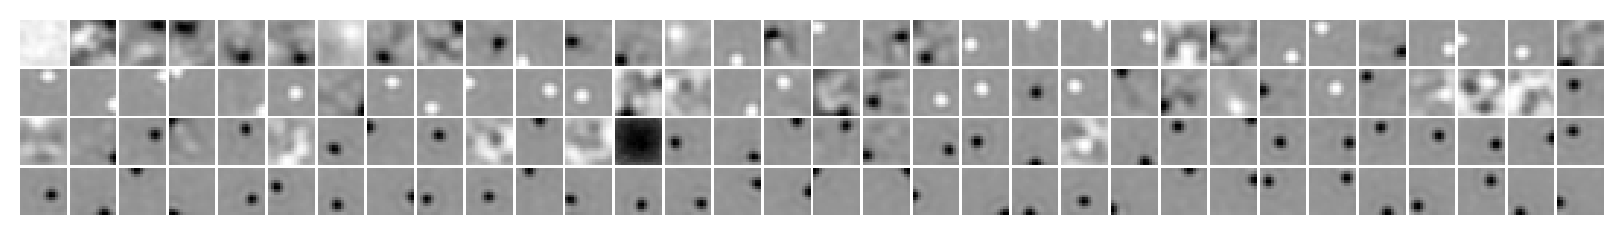

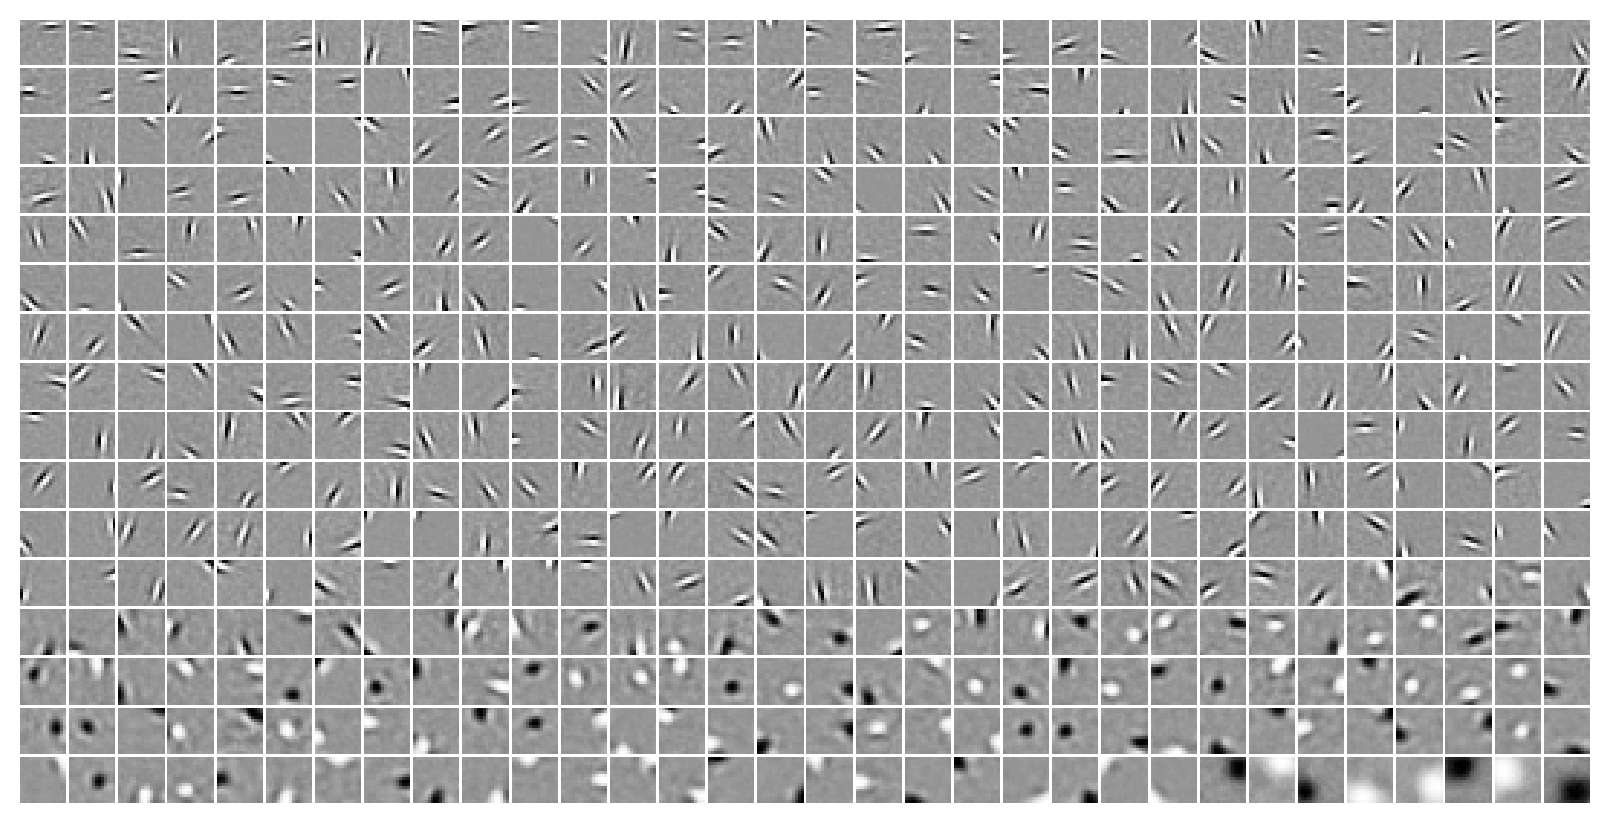

In [5]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for i, (k, v) in enumerate(u0.items()):
    kws = dict(
        order=np.argsort(v),
        method='abs-max',
    )
    tr.model.show(k, **kws);

In [6]:
output = tr.xtract_ftr(t_total=40, save_freq=1, n_data_batches=1)
list(output)

100%|███████████████████████████████████| 1/1 [00:00<00:00,  3.13it/s]


['g0', 'p1', 'times']

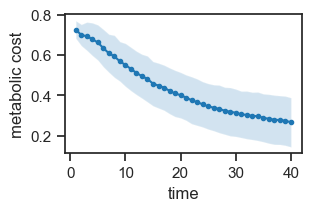

In [8]:
metabolic_cost_mean = tonp(output['p1']['samples'].mean(-1).mean(0))
metabolic_cost_std = tonp(output['p1']['samples'].mean(-1).std(0))

fig, ax = create_figure(1, 1)
ax.plot(output['times'],  metabolic_cost_mean, marker='.')
lower = metabolic_cost_mean - metabolic_cost_std
upper = metabolic_cost_mean + metabolic_cost_std
ax.fill_between(output['times'], lower, upper, alpha=0.2)
ax.set(xlabel='time', ylabel='metabolic cost')
# ax.set(xscale='log')
plt.show()

## Prepare gratings

In [10]:
from analysis.tuning import drifting_grating_feeder, drifting_grating_feeder_params
from utils.animation import show_movie

In [11]:
theta_delta = 10
contrast = 1.0
s_freq = 3.0

param_grid = drifting_grating_feeder_params(
    theta_min=0.0,
    theta_max=170.0,
    theta_delta=theta_delta,
    contrast_min=contrast,
    contrast_max=contrast,
    s_freq_min=s_freq,
    s_freq_max=s_freq,
)

delta_phase = 45
n_frames_for_full_cycle = int(np.ceil(360 / delta_phase))

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [12]:
frames = []
for t in range(n_frames_for_full_cycle):
    frame = feeder[t]
    frames.append(frame)
frames = torch.stack(frames)
frames.shape

torch.Size([8, 18, 256])

In [13]:
show_movie(frames[:, 0, :].reshape(-1, 16, 16))

## Dead neuron detection

In [14]:
stimuli = frames.flatten(end_dim=1)
stimuli.shape

torch.Size([144, 256])

In [21]:
t_total = 1000
spikes = np.empty((len(stimuli), t_total, 512))
r2 = np.empty((len(stimuli), t_total))

tr.model.reset_inference_state(len(stimuli))

for t in tqdm(range(t_total)):
    tr.model.update_time(t)
    extras = tr.model.xtract_ftr(stimuli, return_extras=['samples', 'r2'])[-1]
    spikes[:, t, :] = tonp(extras['p1']['samples'])
    r2[:, t] = tonp(extras['p1']['r2'])

100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 296.46it/s]


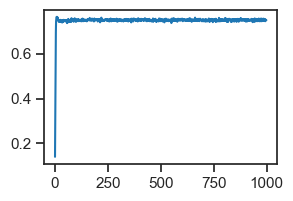

In [22]:
plot(r2.mean(0))
plt.show()

In [23]:
r2.mean(0)[-5:]

array([0.7530551 , 0.7497446 , 0.74975637, 0.75007284, 0.74946661])

In [24]:
spk_mu = spikes.mean(0)
spk_sd = spikes.std(0)
spk_snr = spk_mu / np.maximum(spk_sd, 1e-5)

spk_mu.shape, spk_sd.shape

((1000, 512), (1000, 512))

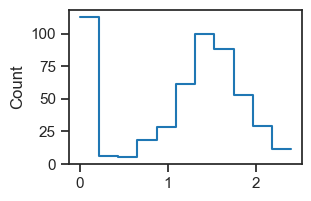

In [35]:
histplot(spk_sd[-1])
plt.show()

In [36]:
active = spk_sd[-1] > 2
active.sum()

35

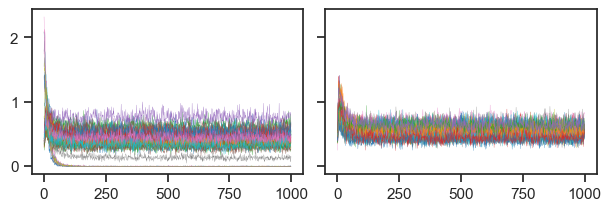

In [37]:
fig, axes = create_figure(1, 2, sharey='all')
axes[0].plot(spk_mu[:, :40], lw=0.2)
axes[1].plot(spk_mu[:, active], lw=0.2)
plt.show()

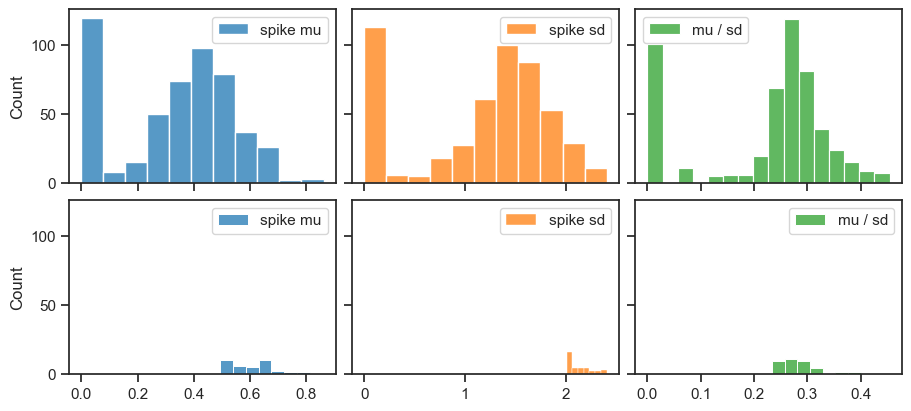

In [38]:
fig, axes = create_figure(2, 3, sharex='col', sharey='all')
sns.histplot(spk_mu[-1], label='spike mu', ax=axes[0, 0])
sns.histplot(spk_sd[-1], label='spike sd', color='C1', ax=axes[0, 1])
sns.histplot(spk_snr[-1], label='mu / sd', color='C2', ax=axes[0, 2])

sns.histplot(spk_mu[-1][active], label='spike mu', ax=axes[1, 0])
sns.histplot(spk_sd[-1][active], label='spike sd', color='C1', ax=axes[1, 1])
sns.histplot(spk_snr[-1][active], label='mu / sd', color='C2', ax=axes[1, 2])

add_legend(axes)
plt.show()

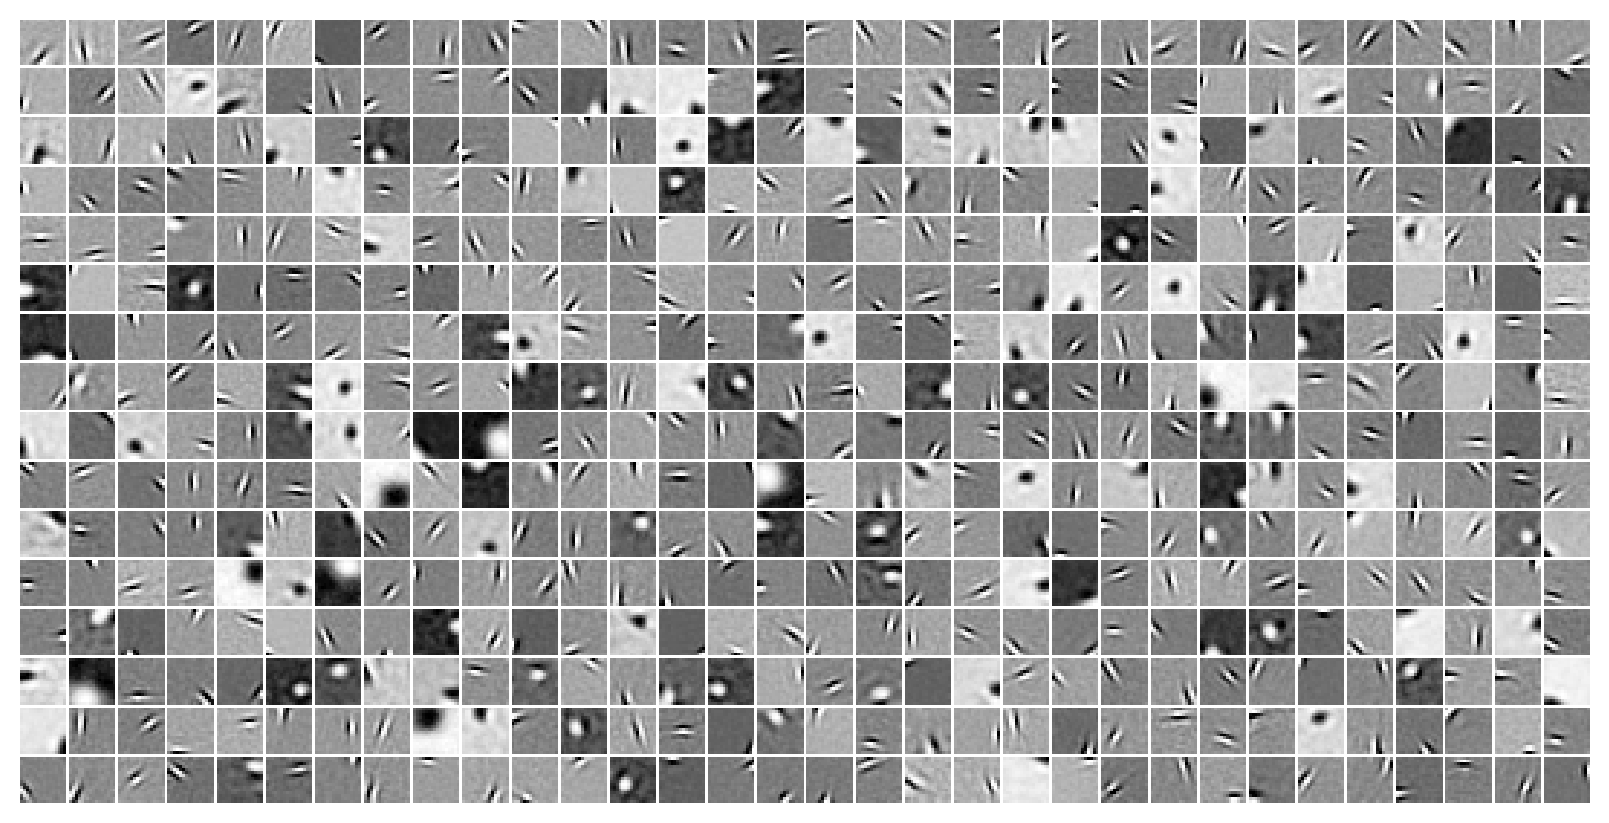

In [39]:
tr.model.show('p1', order=np.argsort(active)[::-1]);

## experiment

In [40]:
stimuli = frames.flatten(end_dim=1)
vld_set = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)

stimuli.shape, vld_set.shape

(torch.Size([144, 256]), torch.Size([9821, 256]))

In [41]:
n_sessions = 4
t_presentation = 500
n_trials_per_batch = 3
batch_size = 3000
n_trials = n_trials_per_batch * batch_size

In [43]:
phi = tonp(tr.model.layers['p1'].get_weight())
w = phi.T @ phi

order = 2
norms_phi = np.linalg.norm(phi, ord=order, axis=0)
norms_w = np.linalg.norm(w, ord=order, axis=0)

norms_phi.shape, norms_w.shape

((512,), (512,))

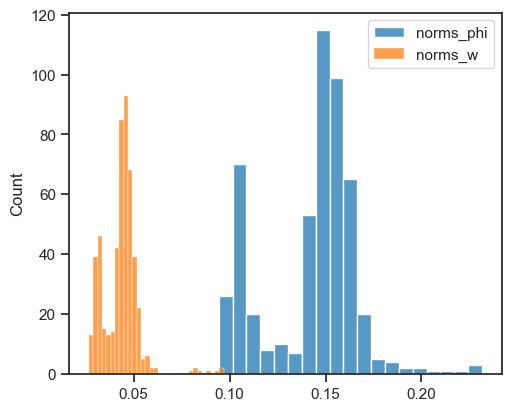

In [44]:
fig, ax = create_figure(1, 1, (5, 4))
sns.histplot(norms_phi, color='C0', label='norms_phi', ax=ax)
sns.histplot(norms_w, color='C1', label='norms_w', ax=ax)
add_legend(ax)
plt.show()

In [45]:
stim_ids = []

shape = (n_sessions, batch_size, t_presentation * n_trials_per_batch)
spikes = np.empty((*shape, 512))
metabolic_cost = np.empty(shape)
normalzied_metabolic_cost = np.empty(shape)
portion_zeros = np.empty(shape)
r2 = np.empty(shape)

for ses_i in tqdm(range(n_sessions)):
    rng = get_rng(ses_i)
    ids = rng.choice(len(stimuli), size=n_trials)
    stim_ids.append(ids)
    x = stimuli[ids].reshape(batch_size, n_trials_per_batch, -1)

    # ids = rng.choice(len(vld_set), size=n_trials, replace=False)
    # x = vld_set[ids].reshape(batch_size, n_trials_per_batch, -1)

    tr.model.cfg.set_seeds(ses_i)
    tr.model.reset_inference_state(len(x))

    for trial_i in range(n_trials_per_batch):
        current_x = x[:, trial_i]
        for time_i in range(t_presentation):
            t = trial_i * t_presentation + time_i
            tr.model.update_time(t)
            extras = tr.model.xtract_ftr(current_x, return_extras=['samples', 'r2'])[-1]
            output = extras['p1']
            # if trial_i == 2:  # skip first trial, treat it as warmup
            
            spikes = tonp(output['samples'])
            spikes = spikes[:, active]
            n = norms_w[active]
    
            cost = spikes * n.reshape(1, -1)
            cost = np.mean(cost, axis=1) / np.sum(n)
            normalzied_metabolic_cost[ses_i, :, t] = cost
            metabolic_cost[ses_i, :, t] = np.mean(spikes, axis=1)
            portion_zeros[ses_i, :, t] = np.mean(spikes == 0, axis=1)
            r2[ses_i, :, t] = tonp(output['r2'])

100%|█████████████████████████████████████████████| 4/4 [00:26<00:00,  6.56s/it]


In [46]:
normalzied_metabolic_cost.shape

(4, 3000, 1500)

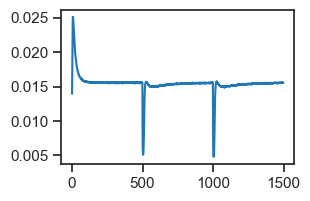

In [47]:
plot(np.mean(normalzied_metabolic_cost, axis=(0, 1)), marker='none')
plt.show()

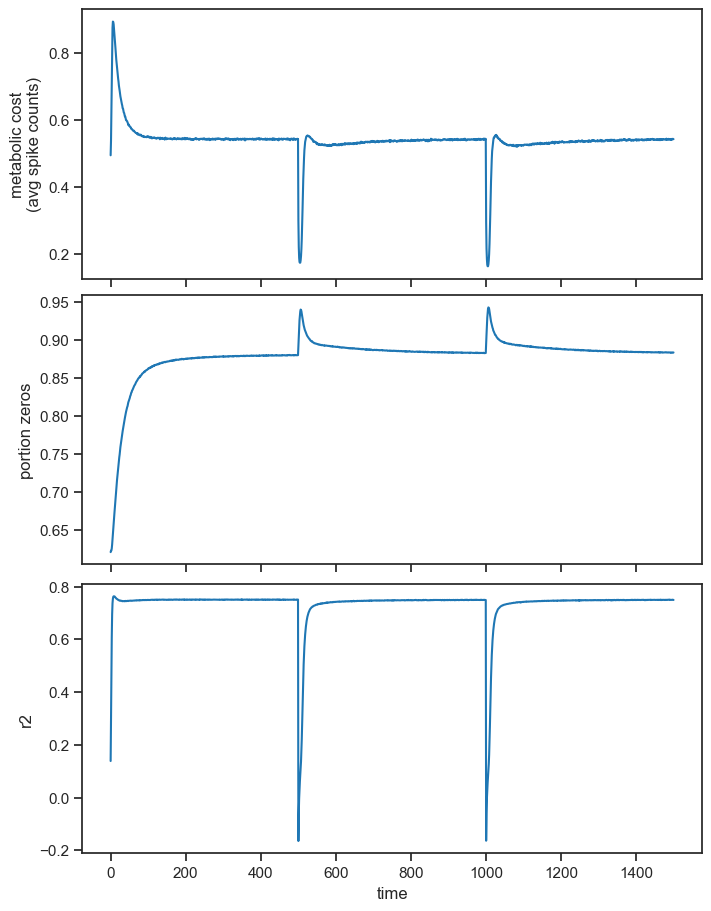

In [48]:
fig, axes = create_figure(3, 1, (7, 9), sharex='all')

axes[0].plot(np.mean(metabolic_cost, axis=(0, 1)), marker='none')
axes[1].plot(np.mean(portion_zeros, axis=(0, 1)), marker='none')
axes[2].plot(np.mean(r2, axis=(0, 1)), marker='none')

axes[0].set(ylabel='metabolic cost\n(avg spike counts)')
axes[1].set(ylabel='portion zeros')
axes[2].set(xlabel='time', ylabel='r2')

plt.show()

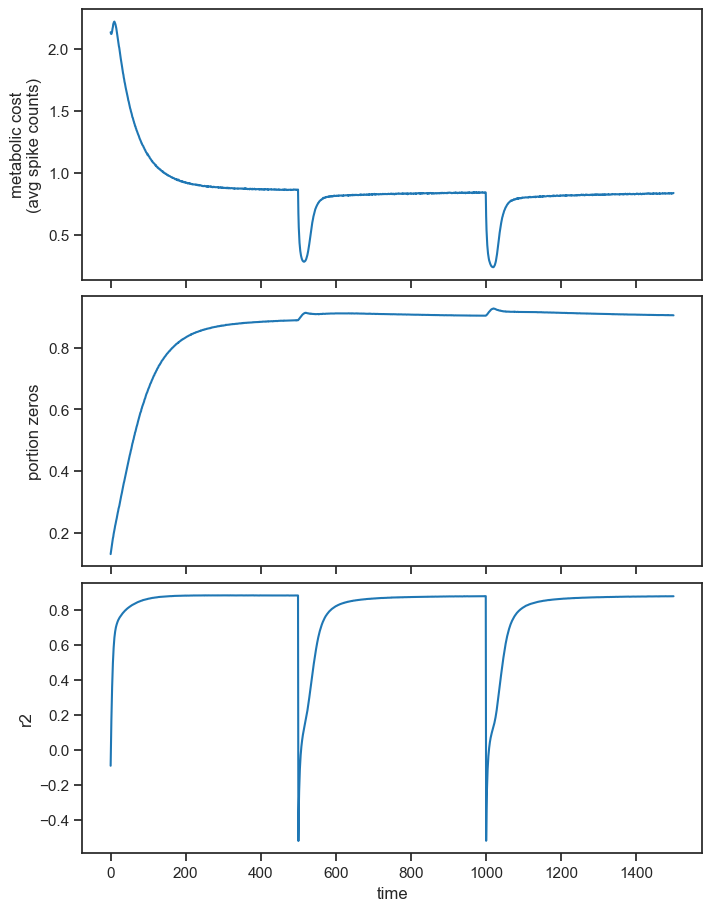

In [178]:
## Was: ipvae